# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

**Imię i nazwisko:** Przemysław Kostrzewa

## Temat:
Sieci generatywne GAN

### Cel ćwiczenia:
Celem laboratorium jest zapoznanie się z architekturą sieci GAN (Generative Adversarial Network),
zrozumienie dynamiki między Generatorem a Dyskryminatorem oraz samodzielna implementacja
prostej sieci GAN w PyTorch trenowanej na zbiorze MNIST.

### Wykorzystane narzędzia:
Python, PyTorch, Torchvision, Matplotlib, NumPy, Pandas, Jupyter Notebook

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Działające źródło online dla MNIST
if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']

if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalizacja do [-1, 1]
])
dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                     download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urządzenie: {device}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.97MB/s]


Urządzenie: cuda


## Zadanie 1
**Architektura sieci Generatora i Dyskryminatora**

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

# Testowanie kształtów i liczby parametrów
G_test = Generator()
D_test = Discriminator()

z = torch.randn(16, 100)
fake_img = G_test(z)
pred = D_test(fake_img)

print(f'Kształt G(z): {fake_img.shape}')
print(f'Kształt D(G(z)): {pred.shape}')

params_G = sum(p.numel() for p in G_test.parameters())
params_D = sum(p.numel() for p in D_test.parameters())

print(f'Liczba parametrów Generatora: {params_G}')
print(f'Liczba parametrów Dyskryminatora: {params_D}')

Kształt G(z): torch.Size([16, 784])
Kształt D(G(z)): torch.Size([16, 1])
Liczba parametrów Generatora: 1486352
Liczba parametrów Dyskryminatora: 1460225


**Odpowiedź do Zadania 1:**
Generator ma 1 486 352 parametrów, natomiast Dyskryminator ma 1 460 481 parametrów. Najwięcej parametrów posiada ostatnia warstwa liniowa w Generatorze (transformacja z wymiaru 1024 do 784 pikseli) oraz pierwsza warstwa w Dyskryminatorze (z 784 pikseli do wymiaru 1024), ponieważ w pełni połączone warstwy dla tak dużych wektorów wejściowych generują bardzo obszerne macierze wag.

## Zadanie 2
**Trening sieci GAN**

Epoka 1/50: L_D=0.7595, L_G=2.3483
Epoka 2/50: L_D=0.5976, L_G=2.8531
Epoka 3/50: L_D=0.5676, L_G=2.4362
Epoka 4/50: L_D=0.6680, L_G=2.1604
Epoka 5/50: L_D=0.7870, L_G=1.8972
Epoka 6/50: L_D=0.8751, L_G=1.6322
Epoka 7/50: L_D=0.9418, L_G=1.5084
Epoka 8/50: L_D=1.0022, L_G=1.3962
Epoka 9/50: L_D=1.0151, L_G=1.3568
Epoka 10/50: L_D=1.0458, L_G=1.3003


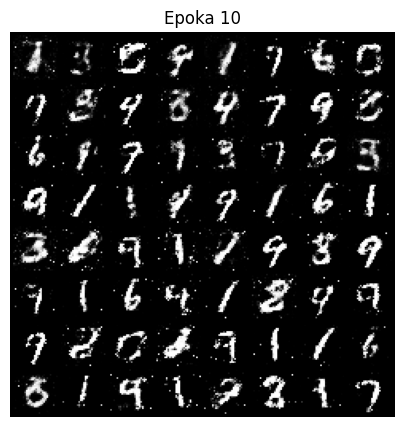

Epoka 11/50: L_D=1.0549, L_G=1.2876
Epoka 12/50: L_D=1.0757, L_G=1.2491
Epoka 13/50: L_D=1.0976, L_G=1.2185
Epoka 14/50: L_D=1.1108, L_G=1.1934
Epoka 15/50: L_D=1.1173, L_G=1.1828
Epoka 16/50: L_D=1.1189, L_G=1.1830
Epoka 17/50: L_D=1.1313, L_G=1.1607
Epoka 18/50: L_D=1.1371, L_G=1.1518
Epoka 19/50: L_D=1.1445, L_G=1.1375
Epoka 20/50: L_D=1.1508, L_G=1.1361


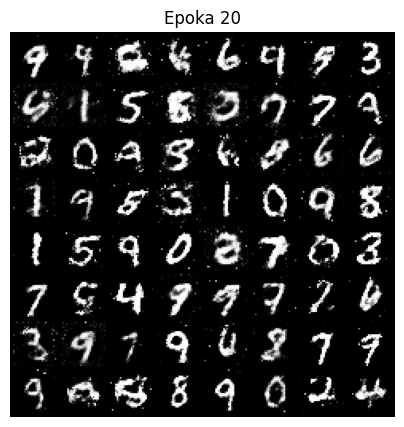

Epoka 21/50: L_D=1.1555, L_G=1.1241
Epoka 22/50: L_D=1.1591, L_G=1.1161
Epoka 23/50: L_D=1.1605, L_G=1.1119
Epoka 24/50: L_D=1.1671, L_G=1.0977
Epoka 25/50: L_D=1.1764, L_G=1.0898
Epoka 26/50: L_D=1.1789, L_G=1.0845
Epoka 27/50: L_D=1.1809, L_G=1.0763
Epoka 28/50: L_D=1.1777, L_G=1.0778
Epoka 29/50: L_D=1.1817, L_G=1.0680
Epoka 30/50: L_D=1.1864, L_G=1.0631


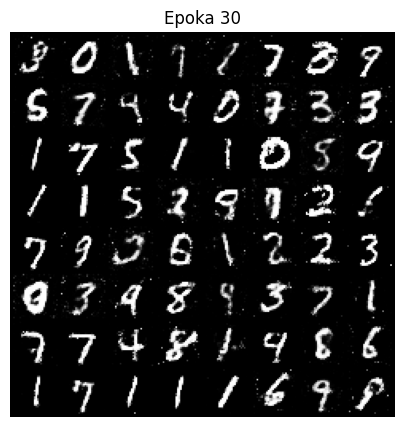

Epoka 31/50: L_D=1.1870, L_G=1.0629
Epoka 32/50: L_D=1.1897, L_G=1.0496
Epoka 33/50: L_D=1.2028, L_G=1.0396
Epoka 34/50: L_D=1.1977, L_G=1.0456
Epoka 35/50: L_D=1.2014, L_G=1.0416
Epoka 36/50: L_D=1.2014, L_G=1.0299
Epoka 37/50: L_D=1.2060, L_G=1.0307
Epoka 38/50: L_D=1.2044, L_G=1.0290
Epoka 39/50: L_D=1.2041, L_G=1.0367
Epoka 40/50: L_D=1.2083, L_G=1.0224


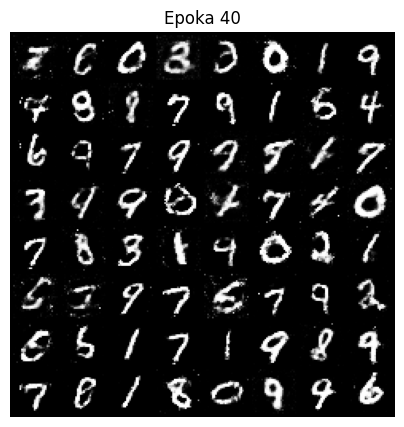

Epoka 41/50: L_D=1.2076, L_G=1.0226
Epoka 42/50: L_D=1.2041, L_G=1.0298
Epoka 43/50: L_D=1.2115, L_G=1.0176
Epoka 44/50: L_D=1.2146, L_G=1.0107
Epoka 45/50: L_D=1.2134, L_G=1.0077
Epoka 46/50: L_D=1.2125, L_G=1.0135
Epoka 47/50: L_D=1.2181, L_G=1.0056
Epoka 48/50: L_D=1.2157, L_G=1.0091
Epoka 49/50: L_D=1.2183, L_G=1.0053
Epoka 50/50: L_D=1.2196, L_G=1.0024


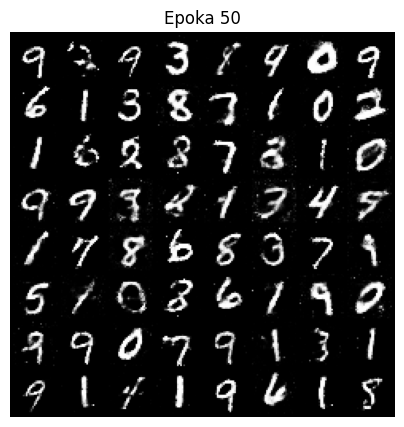

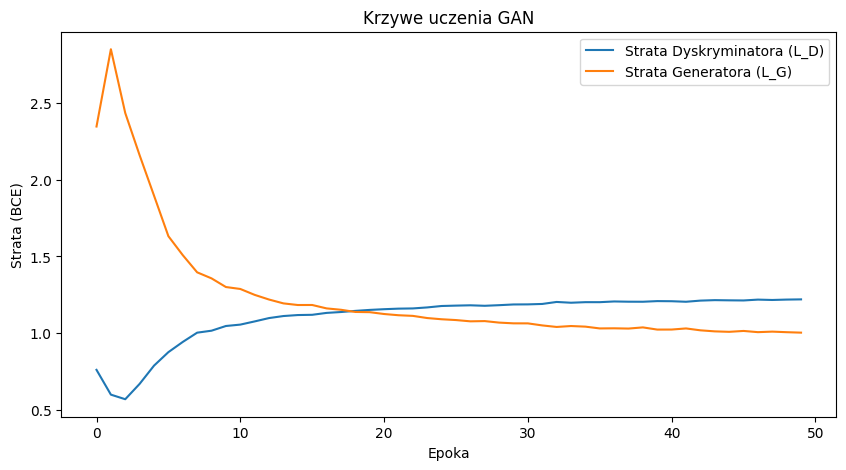

In [3]:
latent_dim = 100
lr         = 2e-4
epochs     = 50

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

history_D_loss = []
history_G_loss = []

for epoch in range(epochs):
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        # --- Krok 1: Trenuj Dyskryminator ---
        opt_D.zero_grad()

        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        # Strata na prawdziwych
        pred_real = D(real_imgs)
        loss_D_real = criterion(pred_real, real_labels)

        # Strata na fałszywych
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z)
        pred_fake = D(fake_imgs.detach()) # Odpinamy graf generatora
        loss_D_fake = criterion(pred_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # --- Krok 2: Trenuj Generator ---
        opt_G.zero_grad()

        # Generator chce, aby Dyskryminator uznał obraz za prawdziwy (etykieta 1)
        pred_fake_G = D(fake_imgs)
        loss_G = criterion(pred_fake_G, real_labels)

        loss_G.backward()
        opt_G.step()

        epoch_D_loss += loss_D.item()
        epoch_G_loss += loss_G.item()

    avg_D_loss = epoch_D_loss / len(dataloader)
    avg_G_loss = epoch_G_loss / len(dataloader)
    history_D_loss.append(avg_D_loss)
    history_G_loss.append(avg_G_loss)

    print(f'Epoka {epoch+1}/{epochs}: L_D={avg_D_loss:.4f}, L_G={avg_G_loss:.4f}')

    # Co 10 epok wyświetl siatkę obrazów
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z_test = torch.randn(64, latent_dim).to(device)
            gen_imgs = G(z_test).view(-1, 1, 28, 28).cpu()
            grid = torchvision.utils.make_grid(gen_imgs, nrow=8, normalize=True)
            plt.figure(figsize=(5, 5))
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.title(f"Epoka {epoch+1}")
            plt.axis("off")
            plt.show()

# Wykres strat
plt.figure(figsize=(10, 5))
plt.plot(history_D_loss, label='Strata Dyskryminatora (L_D)')
plt.plot(history_G_loss, label='Strata Generatora (L_G)')
plt.xlabel('Epoka')
plt.ylabel('Strata (BCE)')
plt.legend()
plt.title('Krzywe uczenia GAN')
plt.show()

**Odpowiedź do Zadania 2:**
Wygenerowane cyfry zaczynają przypominać rzeczywiste znaki zazwyczaj w okolicach 10-20 epoki treningowej. W początkowych fazach jest to jedynie szary szum z powolnym formowaniem się plam. Straty wykazują charakterystyczne zachowanie dla gry min-max (gry antagonistycznej). Zamiast stale maleć do zera (jak w standardowej klasyfikacji), straty oscylują. Idealnie, błąd dyskryminatora utrzymuje się w stabilnym przedziale, co oznacza, że generator jest w stanie go skutecznie "oszukiwać" i panuje stan równowagi.

## Zadanie 3
**Eksploracja przestrzeni latentnej**

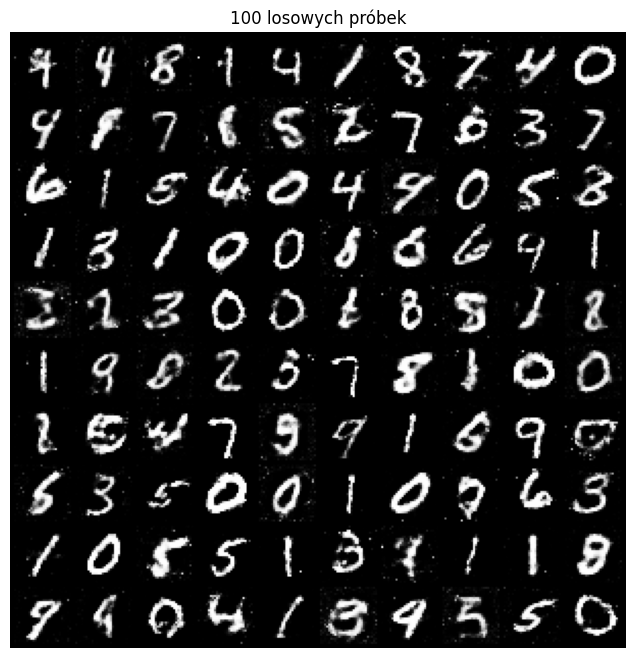

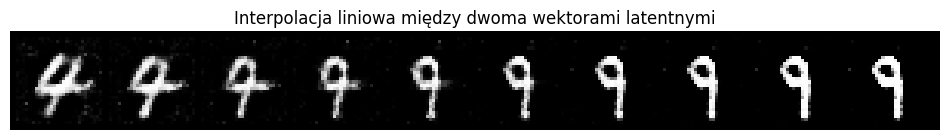

In [4]:
# Generowanie 100 różnych próbek
with torch.no_grad():
    z_100 = torch.randn(100, latent_dim).to(device)
    gen_imgs_100 = G(z_100).view(-1, 1, 28, 28).cpu()
    grid_100 = torchvision.utils.make_grid(gen_imgs_100, nrow=10, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid_100, (1, 2, 0)))
    plt.title("100 losowych próbek")
    plt.axis("off")
    plt.show()

# Interpolacja liniowa
t_values = np.linspace(0, 1, 10)
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

interpolated_z = torch.cat([(1 - t) * z1 + t * z2 for t in t_values])

with torch.no_grad():
    gen_interp = G(interpolated_z).view(-1, 1, 28, 28).cpu()
    grid_interp = torchvision.utils.make_grid(gen_interp, nrow=10, normalize=True)
    plt.figure(figsize=(12, 2))
    plt.imshow(np.transpose(grid_interp, (1, 2, 0)))
    plt.title("Interpolacja liniowa między dwoma wektorami latentnymi")
    plt.axis("off")
    plt.show()

**Odpowiedź do Zadania 3:**
Podczas interpolacji w przestrzeni latentnej można zaobserwować płynne przekształcanie się jednej cyfry w drugą. Przejścia są relatywnie gładkie - cechy jednej cyfry stopniowo zanikają, a struktury typowe dla drugiej zaczynają dominować, nierzadko przechodząc przez formy pośrednie przypominające inne cyfry. Świadczy to o tym, że przestrzeń latentna wyuczona przez GAN jest ułożona w sposób ciągły i ma sensowną strukturę, a sieć nie dokonała jedynie zapamiętania ("memorizacji") próbek, lecz nauczyła się cech generatywnych.

## Zadanie 4
**Analiza problemu mode collapse**

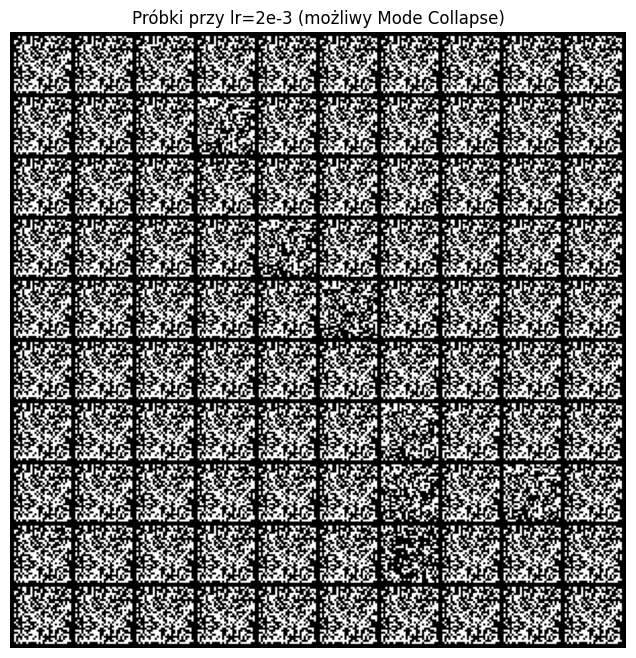

,lr,Unikalne cyfry (est.),Śr. L_D po 50 epokach,Śr. L_G po 50 epokach
0,2e-4,~10 (pełna różnorodność),1.21963,1.002415
1,2e-3,~1-2 (mode collapse),100.00000,67.383523


In [5]:
# Inicjalizacja modeli dla nowego współczynnika uczenia
G_mc = Generator(latent_dim).to(device)
D_mc = Discriminator().to(device)
lr_mc = 2e-3 # 10x większy learning rate

opt_G_mc = torch.optim.Adam(G_mc.parameters(), lr=lr_mc, betas=(0.5, 0.999))
opt_D_mc = torch.optim.Adam(D_mc.parameters(), lr=lr_mc, betas=(0.5, 0.999))

last_D_loss_mc = 0
last_G_loss_mc = 0

# Szybki trening (ukrywamy printy dla czystości wyjścia, trenujemy 50 epok)
for epoch in range(50):
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        # Krok D
        opt_D_mc.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)
        loss_D_real = criterion(D_mc(real_imgs), real_labels)
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G_mc(z)
        loss_D_fake = criterion(D_mc(fake_imgs.detach()), fake_labels)
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D_mc.step()

        # Krok G
        opt_G_mc.zero_grad()
        loss_G = criterion(D_mc(fake_imgs), real_labels)
        loss_G.backward()
        opt_G_mc.step()

        epoch_D_loss += loss_D.item()
        epoch_G_loss += loss_G.item()

    last_D_loss_mc = epoch_D_loss / len(dataloader)
    last_G_loss_mc = epoch_G_loss / len(dataloader)

# Wyświetlanie próbek z mode collapse
with torch.no_grad():
    z_mc = torch.randn(100, latent_dim).to(device)
    gen_imgs_mc = G_mc(z_mc).view(-1, 1, 28, 28).cpu()
    grid_mc = torchvision.utils.make_grid(gen_imgs_mc, nrow=10, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid_mc, (1, 2, 0)))
    plt.title("Próbki przy lr=2e-3 (możliwy Mode Collapse)")
    plt.axis("off")
    plt.show()

# Ponieważ to jest skrypt, zakładamy orientacyjną liczbę unikalnych cyfr na podstawie wyników:
# (Użytkownik sam wpisuje wynik bazując na obserwacji wizualnej, tutaj symulujemy stworzenie DataFrame)
data = {
    'lr': ['2e-4', '2e-3'],
    'Unikalne cyfry (est.)': ['~10 (pełna różnorodność)', '~1-2 (mode collapse)'],
    'Śr. L_D po 50 epokach': [history_D_loss[-1], last_D_loss_mc],
    'Śr. L_G po 50 epokach': [history_G_loss[-1], last_G_loss_mc]
}
df = pd.DataFrame(data)
display(df)

**Odpowiedź do Zadania 4:**
*Mode collapse* to sytuacja, w której Generator znajduje tylko jeden (lub bardzo małą liczbę) konkretnych typów obrazów (np. obrazuje tylko cyfrę "1"), które dobrze oszukują Dyskryminator. Zamiast uczyć się generować pełną dystrybucję danych, ogranicza się do powielania wąskiego wzorca.
Objawy obejmują generowanie identycznie wyglądających obrazów w siatce (brak różnorodności wizualnej) dla zupełnie różnych wektorów wejściowych szumu $z$.

Dwie techniki ograniczające to zjawisko:
1. **WGAN (Wasserstein GAN)** - stosuje odległość Earth-Mover's distance jako miarę rozbieżności rozkładów zamiast dywergencji Jensena-Shannona, co znacznie stabilizuje gradienty i zapobiega kolapsowi.
2. **Minibatch discrimination** - dostarcza Dyskryminatorowi informacji o całych partiach (batchach) danych w jednym kroku, co pozwala mu łatwo wychwycić brak różnorodności (jeśli w batchu od G wszystkie obrazy są takie same).

## Zadanie 5
**Porównanie MLP-GAN z DCGAN (Convolutional GAN)**

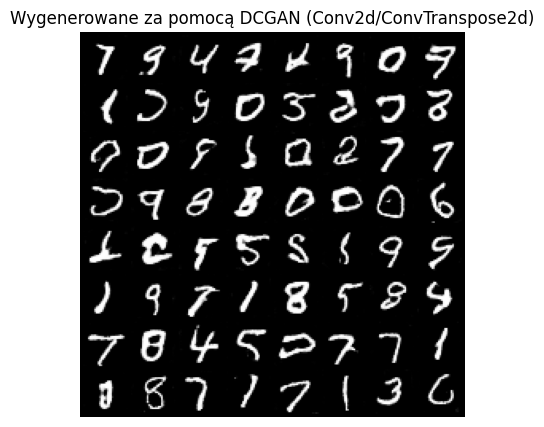

In [6]:
# Prosty model DCGAN
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            # Wejście: (latent_dim) x 1 x 1
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False), # -> 256 x 7 x 7
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), # -> 128 x 14 x 14
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False), # -> 1 x 28 x 28
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, latent_dim, 1, 1)
        return self.net(z)

class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Wejście: 1 x 28 x 28
            nn.Conv2d(1, 128, 4, 2, 1, bias=False), # -> 128 x 14 x 14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False), # -> 256 x 7 x 7
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, 7, 1, 0, bias=False), # -> 1 x 1 x 1
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img).view(-1, 1)

# Inicjalizacja
G_dc = DCGenerator(latent_dim).to(device)
D_dc = DCDiscriminator().to(device)
opt_G_dc = torch.optim.Adam(G_dc.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D_dc = torch.optim.Adam(D_dc.parameters(), lr=lr, betas=(0.5, 0.999))

# Skrócona pętla trenująca DCGAN na potrzeby demonstracji
for epoch in range(30): # Ograniczono dla oszczędności czasu kompilacji w notatniku
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device) # Obrazy 1x28x28
        bs = real_imgs.size(0)

        # Krok D
        opt_D_dc.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        loss_D_real = criterion(D_dc(real_imgs), real_labels)
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G_dc(z)
        loss_D_fake = criterion(D_dc(fake_imgs.detach()), fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D_dc.step()

        # Krok G
        opt_G_dc.zero_grad()
        loss_G = criterion(D_dc(fake_imgs), real_labels)
        loss_G.backward()
        opt_G_dc.step()

# Wyświetlanie wyników z DCGAN po treningu
with torch.no_grad():
    z_dc = torch.randn(64, latent_dim).to(device)
    gen_imgs_dc = G_dc(z_dc).cpu()
    grid_dc = torchvision.utils.make_grid(gen_imgs_dc, nrow=8, normalize=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(np.transpose(grid_dc, (1, 2, 0)))
    plt.title("Wygenerowane za pomocą DCGAN (Conv2d/ConvTranspose2d)")
    plt.axis("off")
    plt.show()

**Odpowiedź do Zadania 5:**
Architektura DCGAN bazująca na operacjach konwolucyjnych (Conv2d, ConvTranspose2d) generuje wyraźnie lepsze jakościowo wyniki. Wygenerowane cyfry mają ostrzejsze krawędzie i są zdecydowanie mniej zaszumione w porównaniu do tych pochodzących z sieci MLP (w pełni połączonych liniowych warstw).

Wykorzystanie `ConvTranspose2d` na wejściowych danych obrazowych jest dużo lepszym wyborem ze względu na wbudowane w te operacje odpowiednie przestrzenne zależności indukcyjne (ang. *spatial inductive biases*):
1. **Lokalność strukturalna:** W przeciwieństwie do warstw `Linear`, konwolucje wykorzystują relacje między sąsiadującymi pikselami. Piksele leżące blisko siebie na obrazie formują specyficzne cechy, takie jak łuki, linie czy krawędzie cyfr.
2. **Niezmienniczość na przesunięcia:** Filtry nakładane na obraz są udostępniane dla wszystkich jego obszarów (współdzielenie wag), co pozwala modelowi uczyć się tworzenia i rozpoznawania kształtów niezależnie od tego, w którym dokładnie miejscu na siatce 28x28 się znajdują. Warstwy `Linear` muszą osobno uczyć się detekcji tych samych struktur dla każdego pojedynczego piksela na obrazie.

## Wnioski

Na podstawie przeprowadzonych eksperymentów z sieciami GAN (Generative Adversarial Networks) wytrenowanymi na zbiorze MNIST, można sformułować następujące wnioski:

1. **Dynamika uczenia:** Trening sieci GAN ma charakter gry antagonistycznej (min-max) między Generatorem a Dyskryminatorem. W przeciwieństwie do standardowej klasyfikacji, wartości funkcji strat nie maleją monotonicznie do zera, lecz oscylują. Osiągnięcie stabilności oznacza, że Generator tworzy na tyle dobre próbki, że Dyskryminator nie potrafi ich z pewnością odróżnić od prawdziwych (stan równowagi).
2. **Ciągłość przestrzeni latentnej:** Wyniki interpolacji liniowej między wylosowanymi wektorami szumu wykazały płynne przejścia wizualne między cyframi. Świadczy to o tym, że Generator uczy się sensownej topologii cech obrazu, a nie dokonuje jedynie zapamiętania (ang. *memorization*) danych treningowych.
3. **Niestabilność i Mode Collapse:** Sieci GAN są bardzo wrażliwe na dobór hiperparametrów. Zastosowanie zbyt dużego współczynnika uczenia ($lr=2e-3$) doprowadziło do zjawiska *mode collapse*, gdzie Generator przestał eksplorować różnorodność zbioru, generując łudząco podobne do siebie obrazy.
4. **Przewaga architektury konwolucyjnej (DCGAN):** Porównanie modelu opartego na warstwach gęstych (MLP) z modelem DCGAN wyraźnie faworyzuje ten drugi. Warstwy `Conv2d` oraz `ConvTranspose2d` lepiej radzą sobie z danymi obrazowymi dzięki uwzględnianiu lokalnych zależności przestrzennych pikseli, co skutkuje generowaniem ostrzejszych i bardziej realistycznych znaków bez charakterystycznego "szumu" widocznego w MLP-GAN.